# Spiral Encoding Variants

Comparing three alternatives for how the outside-in spiral of a 7×7 whorl cell
assigns quantile rank to pixel position.  All three use the **same GTEx data**
(approximate bootstrap distributions from `survey.csv`), the same colormap,
and the same 13×20 grid layout as Figure 1.  Only the spiral fill logic changes.

| Variant | Spiral direction | Assignment | Center pixel |
|---|---|---|---|
| **V1 — baseline** | outside → center | sequential quantile rank | max quantile |
| **V2 — median-center** | center → outside | symmetric interleaved rank | median |
| **V3 — mean-center (Keim)** | center → outside | sorted by deviation from mean | mean |

V3 is included to empirically verify the intermingling concern for cells that
straddle zero.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from pathlib import Path

rng = np.random.default_rng(42)

CMAP = LinearSegmentedColormap.from_list('swo', ['steelblue', 'white', 'orangered'], N=256)
NORM = Normalize(vmin=-1.5, vmax=1.5)

DATA_DIR = Path('../gtex_data')

## Spiral path generators

In [2]:
def spiral_outside_in(n=7):
    """(row, col) pairs in outside-in rectangular spiral order."""
    path, top, bottom, left, right = [], 0, n-1, 0, n-1
    while top <= bottom and left <= right:
        for c in range(left, right+1):  path.append((top, c))
        top += 1
        for r in range(top, bottom+1):  path.append((r, right))
        right -= 1
        if top <= bottom:
            for c in range(right, left-1, -1): path.append((bottom, c))
            bottom -= 1
        if left <= right:
            for r in range(bottom, top-1, -1): path.append((r, left))
            left += 1
    return path

def spiral_inside_out(n=7):
    return list(reversed(spiral_outside_in(n)))

PATH_OUT_IN  = spiral_outside_in(7)  # V1
PATH_IN_OUT  = spiral_inside_out(7)  # V2, V3

N_PIX = 49
print('Spiral path lengths:', len(PATH_OUT_IN), len(PATH_IN_OUT))
print('Center pixel (V1, last):', PATH_OUT_IN[-1])
print('Center pixel (V2/V3, first):', PATH_IN_OUT[0])

Spiral path lengths: 49 49
Center pixel (V1, last): (3, 3)
Center pixel (V2/V3, first): (3, 3)


## Cell rendering — three variants

In [3]:
def render_v1(samples, n=7):
    """V1 — outside-in, sequential quantile rank (baseline)."""
    q = np.linspace(0, 1, N_PIX)
    vals = np.quantile(samples, q)
    img = np.zeros((n, n, 4))
    for i, (r, c) in enumerate(PATH_OUT_IN):
        img[r, c] = CMAP(NORM(vals[i]))
    return img

def render_v2(samples, n=7):
    """V2 — inside-out, symmetric interleaved rank (center = median)."""
    q = np.linspace(0, 1, N_PIX)
    vals = np.quantile(samples, q)
    # Interleave: center gets median, then alternate lower/upper outward
    mid = N_PIX // 2
    interleaved = []
    lo, hi = mid, mid
    interleaved.append(vals[mid])
    for _ in range(mid):
        lo -= 1; interleaved.append(vals[lo])
        hi += 1; interleaved.append(vals[hi])
    img = np.zeros((n, n, 4))
    for i, (r, c) in enumerate(PATH_IN_OUT):
        img[r, c] = CMAP(NORM(interleaved[i]))
    return img

def render_v3(samples, n=7):
    """V3 — inside-out, sorted by |deviation from mean| (Keim). Center = mean.
    
    Uses one representative sample per pixel (evenly spaced after sorting by
    unsigned deviation) rather than averaging a bin — averaging cancels out
    the tails for straddling-zero cells and washes the outer ring to white.
    """
    mean = np.mean(samples)
    order = np.argsort(np.abs(samples - mean))
    sorted_samples = samples[order]
    # Pick one representative per pixel, evenly spaced
    indices = np.linspace(0, len(sorted_samples) - 1, N_PIX, dtype=int)
    vals = sorted_samples[indices]
    img = np.zeros((n, n, 4))
    for i, (r, c) in enumerate(PATH_IN_OUT):
        img[r, c] = CMAP(NORM(vals[i]))
    return img

RENDERERS = {'V1 outside-in\n(baseline)': render_v1,
             'V2 median-center\n(reversed)': render_v2,
             'V3 mean-center\n(Keim)': render_v3}

## Synthesise bootstrap distributions from survey.csv

In [4]:
RIGHT_GENES = [
    'TPH2', 'CHRNA7', 'ESR1',
    'TH', 'SLC6A3', 'DDC', 'AGRP',
    'SST', 'PENK', 'GAD1', 'GAD2', 'CRH',
    'DRD5', 'CHRM1', 'BDNF', 'CYP19A1',
    'AIF1', 'MAOA', 'FKBP5', 'GFAP',
]
REGION_ORDER = [
    'Hypothalamus', 'Amygdala', 'Hippocampus', 'Ant. Cing. Ctx',
    'Frontal Cortex', 'Cortex', 'Caudate', 'Putamen',
    'Nucleus Accumbens', 'Cerebellum', 'Cerebellar Hemi.',
    'Substantia Nigra', 'Spinal Cord',
]

survey = pd.read_csv(DATA_DIR / 'survey.csv')
survey = survey[survey.gene.isin(RIGHT_GENES) & survey.region.isin(REGION_ORDER)]

# Synthesise 5000-sample bootstrap from mean + CI
def synth_bootstrap(row, n=5000):
    se = (row.ci_hi - row.ci_lo) / 3.92  # 95% CI → SE
    return rng.normal(row.mean_md, max(se, 1e-4), n)

bootstraps = {}
for _, row in survey.iterrows():
    bootstraps[(row.gene, row.region)] = synth_bootstrap(row)

print(f'Synthesised {len(bootstraps)} bootstrap distributions')

Synthesised 260 bootstrap distributions


## Full 13×20 whorlmap — all three variants

The three maps below use identical data; only the fill logic differs.
Look especially at cells that straddle zero (V3 intermingling) vs.
cells with strong directional effects (V1 vs V2 gradient direction).

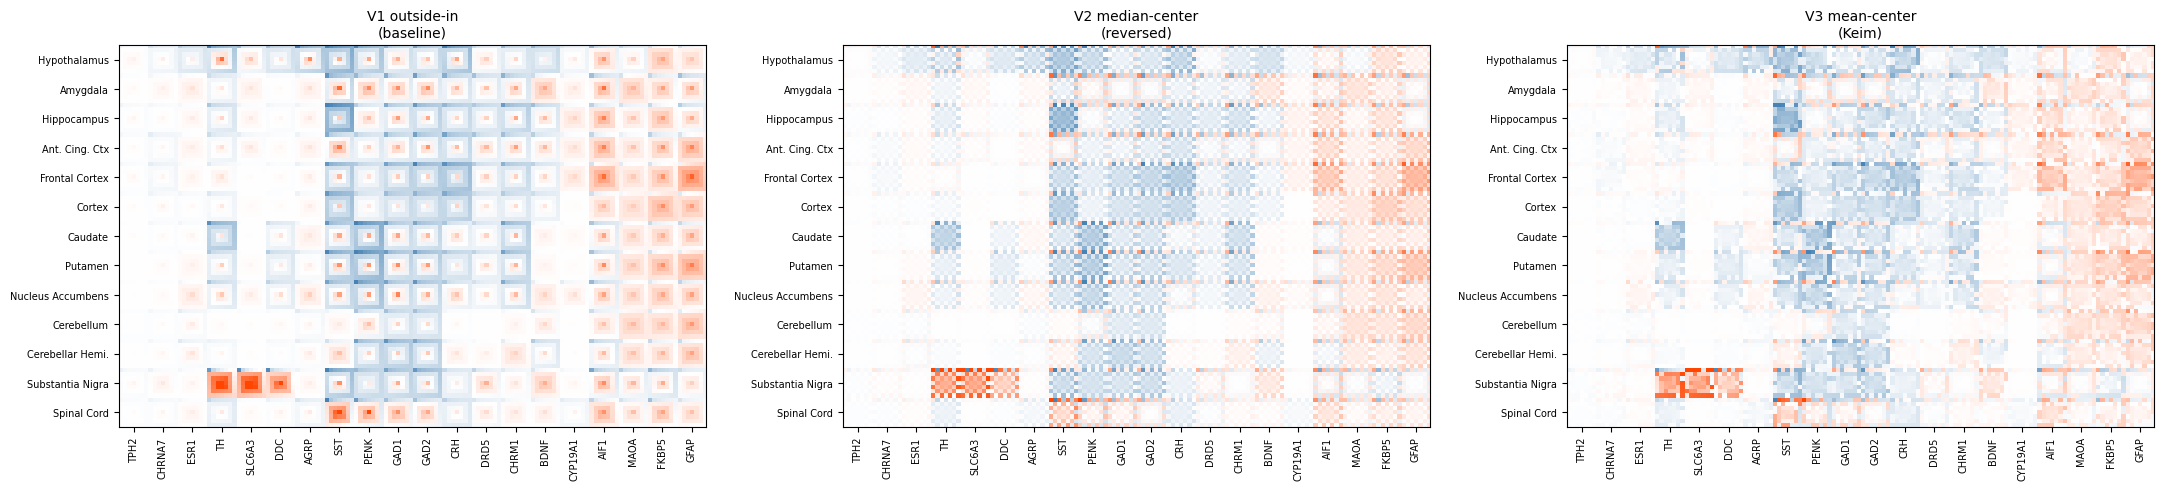

Saved spiral_variants_fullmap.png


In [5]:
ZOOM = 8  # pixels per whorl-cell pixel → each cell = 56×56 px in the map

def draw_whorlmap(renderer, ax, title):
    nrow, ncol = len(REGION_ORDER), len(RIGHT_GENES)
    canvas = np.ones((nrow * 7 * ZOOM, ncol * 7 * ZOOM, 4))
    
    for ri, region in enumerate(REGION_ORDER):
        for ci, gene in enumerate(RIGHT_GENES):
            key = (gene, region)
            if key not in bootstraps:
                continue
            cell_img = renderer(bootstraps[key])  # 7×7×4
            # Scale up by ZOOM
            cell_big = np.repeat(np.repeat(cell_img, ZOOM, axis=0), ZOOM, axis=1)
            r0, c0 = ri * 7 * ZOOM, ci * 7 * ZOOM
            canvas[r0:r0 + 7*ZOOM, c0:c0 + 7*ZOOM] = cell_big
    
    ax.imshow(canvas, interpolation='nearest', aspect='equal')
    ax.set_xticks(np.arange(ncol) * 7 * ZOOM + 3.5 * ZOOM)
    ax.set_xticklabels(RIGHT_GENES, rotation=90, fontsize=7)
    ax.set_yticks(np.arange(nrow) * 7 * ZOOM + 3.5 * ZOOM)
    ax.set_yticklabels(REGION_ORDER, fontsize=7)
    ax.set_title(title, fontsize=10, pad=6)

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
for ax, (label, renderer) in zip(axes, RENDERERS.items()):
    draw_whorlmap(renderer, ax, label)

plt.tight_layout(pad=2)
plt.savefig('spiral_variants_fullmap.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved spiral_variants_fullmap.png')

## Highlighted cells at 10× zoom

The four cells from Figure 1 (a1, a2, b1, b2) shown at 10× magnification
to make the pixel-level structure legible.

| Label | Gene | Region | Expected character |
|---|---|---|---|
| a1 | SST | Spinal Cord | strong directional |
| a2 | FKBP5 | Putamen | crosses zero |
| b1 | AIF1 | Substantia Nigra | strong directional |
| b2 | CYP19A1 | Caudate | mixed / moderate |

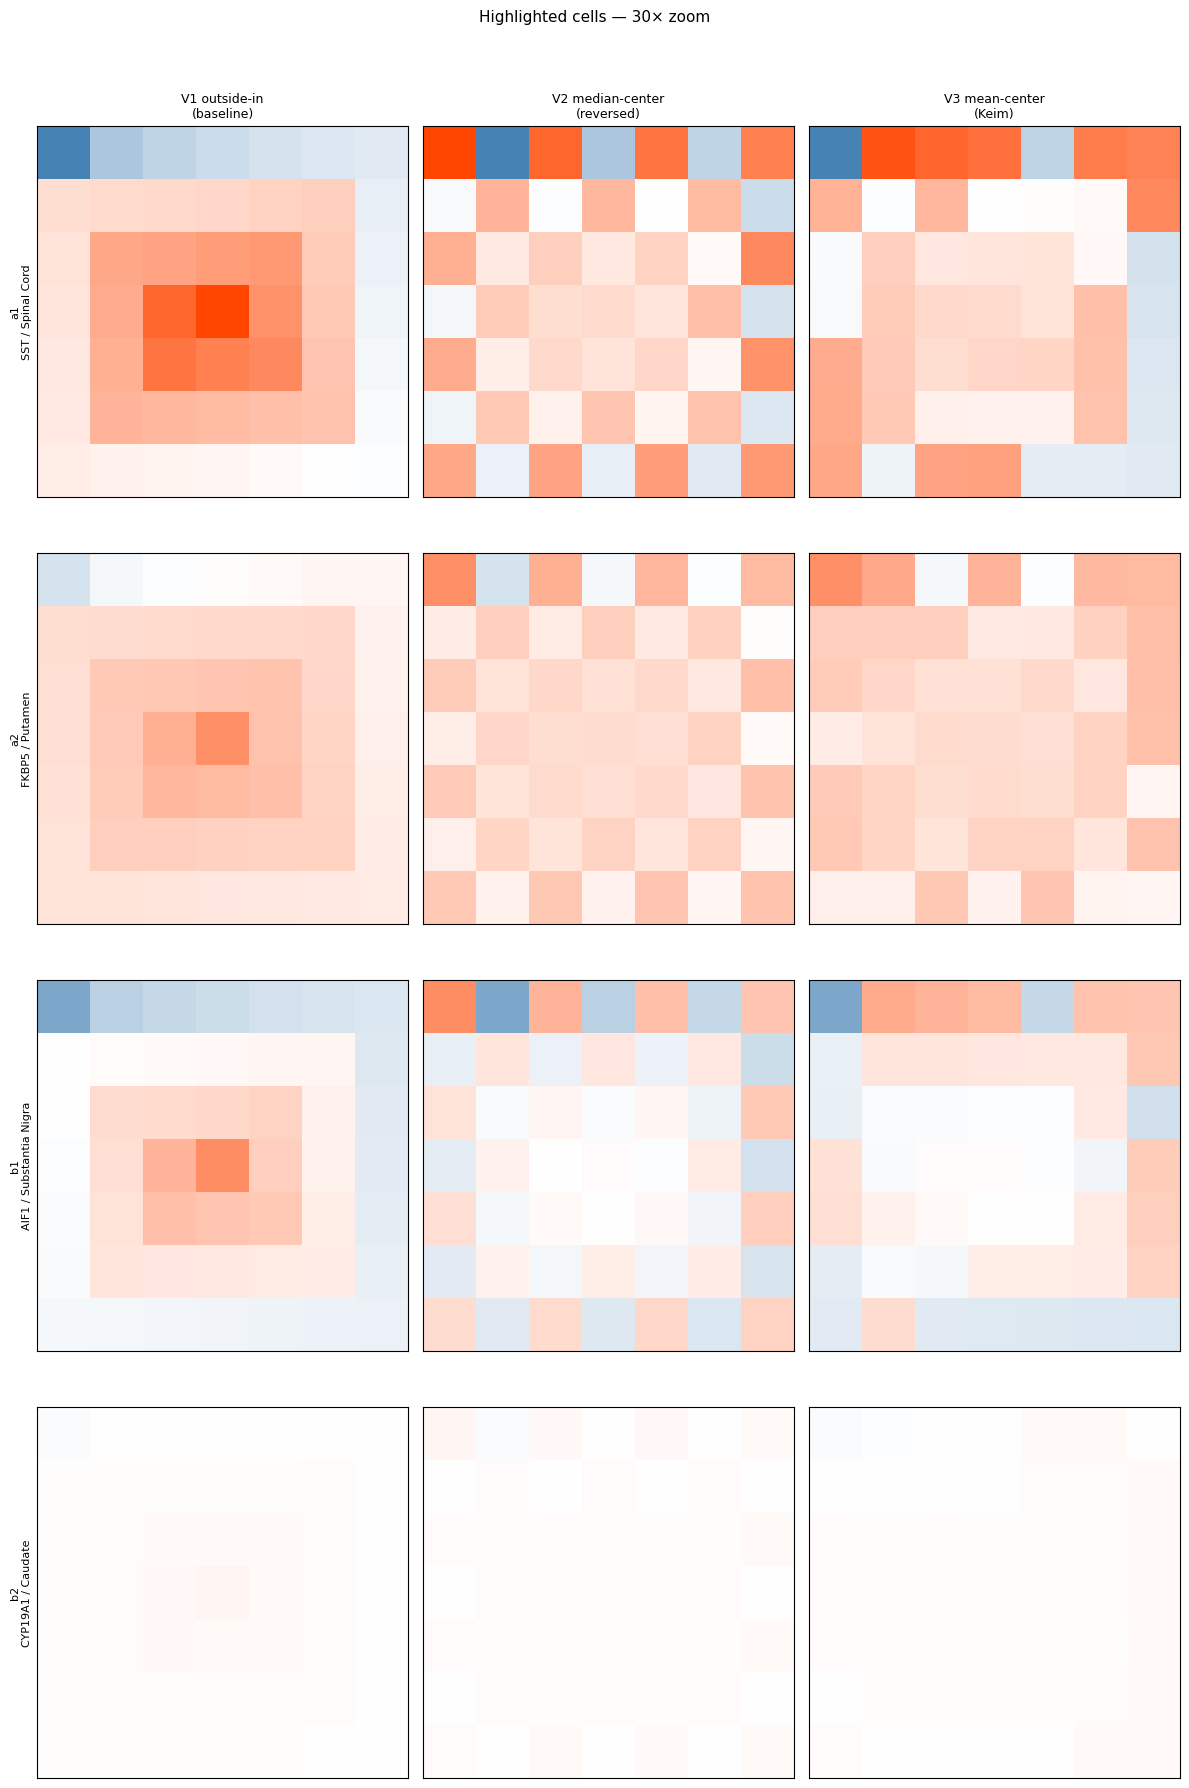

Saved spiral_variants_zoom.png


In [6]:
HIGHLIGHT = [
    ('a1', 'SST',     'Spinal Cord'),
    ('a2', 'FKBP5',   'Putamen'),
    ('b1', 'AIF1',    'Substantia Nigra'),
    ('b2', 'CYP19A1', 'Caudate'),
]
ZOOM_CELL = 30  # pixels per whorl pixel → each cell shown at 210×210 px

fig, axes = plt.subplots(len(HIGHLIGHT), len(RENDERERS),
                          figsize=(4 * len(RENDERERS), 4.5 * len(HIGHLIGHT)))

for row_i, (label, gene, region) in enumerate(HIGHLIGHT):
    samples = bootstraps[(gene, region)]
    for col_j, (vname, renderer) in enumerate(RENDERERS.items()):
        ax = axes[row_i, col_j]
        cell_img = renderer(samples)
        cell_big = np.repeat(np.repeat(cell_img, ZOOM_CELL, axis=0), ZOOM_CELL, axis=1)
        ax.imshow(cell_big, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        if row_i == 0:
            ax.set_title(vname, fontsize=9)
        if col_j == 0:
            ax.set_ylabel(f'{label}\n{gene} / {region}', fontsize=8)

plt.suptitle('Highlighted cells — 30× zoom', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('spiral_variants_zoom.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved spiral_variants_zoom.png')

## Observations

Record visual observations here after running.

- V1 vs V2: does reversing the spiral change readability of the full map?
- V2: is the median visually salient at the center?
- V3: is intermingling visible in straddling-zero cells (a2)?
- Which variant best supports quick scanning of the full 13×20 grid?